In [2]:
import torch
import pandas as pd

print(f"Cuda available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Pandas version: {pd.__version__}")
# Thử lưu một file parquet nhỏ để test pyarrow
pd.DataFrame({'a': [1]}).to_parquet('test.parquet')
print("Mọi thứ đã sẵn sàng!")

Cuda available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Pandas version: 3.0.2
Mọi thứ đã sẵn sàng!


# 1.0 — EDA & Tiền xử lý dữ liệu bão

## Kiến trúc dữ liệu

| File | Loại | Vai trò |
|------|------|---------|
| `hurdat2_data_sach.csv` | **Quỹ đạo** (54 749 dòng, 1851–2023) | Nguồn chính: lat/lon/wind/pressure mỗi 6h |
| `ToanBo_DuLieu_Bao_1996_2025.csv` | **Tác động** NOAA Storm Events | Thiệt hại, thương vong, cấp độ Saffir-Simpson |
| `Du_Lieu_Bao_1996.csv` | Subset 1996 | Kiểm tra & validate |

## Model được chọn: **Bi-LSTM + Transformer Encoder (Hybrid)**

Dựa trên đặc điểm dữ liệu (chuỗi thời gian 6h, 480 cơn bão 1996–2023, đa target):

| Model | Track MAE | Intensity MAE | Tốc độ train | Ghi chú |
|-------|-----------|---------------|--------------|--------|
| LSTM baseline | ~180 km | ~8 kt | Nhanh | Baseline |
| **Bi-LSTM + Attn** | ~130 km | ~6 kt | Trung bình | ✅ Chọn |
| Transformer (TiDE) | ~120 km | ~5.5 kt | Chậm | Ensemble |
| Graph Neural Net | ~115 km | ~5 kt | Rất chậm | Cần NWP data |

> **Output:** `data/processed_storms.parquet` — input cho Notebook 2.0


## 0. Imports & Cấu hình GPU

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
import re, json, warnings, pickle
from pathlib import Path
warnings.filterwarnings('ignore')

# ── GPU check ──────────────────────────────────────────────────────────────────
try:
    import torch
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    if DEVICE == 'cuda':
        print(f'GPU: {torch.cuda.get_device_name(0)}')
        print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    else:
        print('GPU không tìm thấy — chạy trên CPU')
except ImportError:
    DEVICE = 'cpu'
    print('PyTorch chưa cài')

# ── Đường dẫn ──────────────────────────────────────────────────────────────────
DATA_DIR   = Path('.')          # thư mục chứa 3 file CSV
OUTPUT_DIR = Path('data')
PLOT_DIR   = OUTPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

FILE_HURDAT = DATA_DIR / 'hurdat2_data_sach.csv'
FILE_NOAA   = DATA_DIR / 'ToanBo_DuLieu_Bao_1996_2025.csv'
FILE_1996   = DATA_DIR / 'Du_Lieu_Bao_1996.csv'
FILE_OUT    = OUTPUT_DIR / 'processed_storms.parquet'
FILE_OUT_CSV= OUTPUT_DIR / 'processed_storms.csv'

# ── Hằng số ────────────────────────────────────────────────────────────────────
STEP_HOURS  = 6       # khoảng cách quan sát chuẩn HURDAT2
MIN_OBS     = 8       # tối thiểu 8 bước = 48h
YEAR_START  = 1996    # đồng bộ với NOAA Storm Events
YEAR_END    = 2023    # năm cuối của HURDAT2
EARTH_R     = 6371    # km

INTENSITY_COLORS = {
    'TD':'#90caf9','TS':'#42a5f5','C1':'#ffee58',
    'C2':'#ffa726','C3':'#ef5350','C4':'#ab47bc','C5':'#4a148c'
}
STATUS_TO_CLASS = {
    'TD':0,'SD':0,                          # Tropical/Subtropical Depression
    'TS':1,'SS':1,                          # Tropical/Subtropical Storm
    'HU':None,                              # Hurricane → dùng wind speed
    'EX':1,'LO':0,'DB':0,'WV':0,           # Extratropical, Low, Disturbance, Wave
}

print(f'Device : {DEVICE}')
print(f'DATA_DIR: {DATA_DIR.resolve()}')
print(f'OUTPUT  : {OUTPUT_DIR.resolve()}')


GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB
Device : cuda
DATA_DIR: C:\Data\AI\Storm\notebooks
OUTPUT  : C:\Data\AI\Storm\notebooks\data


---
## 1. Load & Khám phá HURDAT2 (nguồn quỹ đạo chính)

In [4]:
from pathlib import Path

# Lấy đường dẫn của thư mục hiện tại chứa file Notebook
BASE_DIR = Path.cwd() 

# Khai báo file bằng cách nối chuỗi an toàn
FILE_HURDAT = BASE_DIR / 'hurdat2_data_sach.csv'

# Kiểm tra file có thực sự tồn tại trước khi đọc
if FILE_HURDAT.exists():
    h2_raw = pd.read_csv(FILE_HURDAT)
    print("Đã load file thành công!")
else:
    print(f"Không tìm thấy file tại: {FILE_HURDAT}")

Không tìm thấy file tại: c:\Data\AI\Storm\notebooks\hurdat2_data_sach.csv


In [5]:
from pathlib import Path

# 1. Xác định thư mục chứa file dữ liệu (nằm trong thư mục 'data' cùng cấp với notebook)
DATA_DIR = Path('.') / 'data' 

# 2. Định nghĩa đường dẫn đầy đủ đến file CSV
FILE_HURDAT = DATA_DIR / 'hurdat2_data_sach.csv'

# 3. Các thư mục đầu ra (Output)
OUTPUT_DIR = Path('.') / 'output' # Nên tách riêng output để tránh lẫn lộn với raw data
PLOT_DIR   = OUTPUT_DIR / 'plots'

# Tạo thư mục nếu chưa có
OUTPUT_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

# --- Kiểm tra và Load data ---
if FILE_HURDAT.exists():
    h2_raw = pd.read_csv(FILE_HURDAT)
    print(f"Đã load file thành công từ: {FILE_HURDAT}")
    print(f'Shape : {h2_raw.shape}')
    display(h2_raw.head(10))
else:
    print(f"LỖI: Không tìm thấy file tại {FILE_HURDAT.absolute()}")
    print("Hãy kiểm tra xem file hurdat2_data_sach.csv có nằm trong thư mục 'data' chưa.")

Đã load file thành công từ: data\hurdat2_data_sach.csv
Shape : (54749, 9)


,Storm_ID,Storm_Name,Date,Time_UTC,Status,Latitude,Longitude,Max_Wind_kt,Min_Pressure_mb
0,AL011851,UNNAMED,18510625,0,HU,28.0N,94.8W,80,NaN
1,AL011851,UNNAMED,18510625,600,HU,28.0N,95.4W,80,NaN
2,AL011851,UNNAMED,18510625,1200,HU,28.0N,96.0W,80,NaN
3,AL011851,UNNAMED,18510625,1800,HU,28.1N,96.5W,80,NaN
4,AL011851,UNNAMED,18510625,2100,HU,28.2N,96.8W,80,NaN
5,AL011851,UNNAMED,18510626,0,HU,28.2N,97.0W,70,NaN
6,AL011851,UNNAMED,18510626,600,TS,28.3N,97.6W,60,NaN
7,AL011851,UNNAMED,18510626,1200,TS,28.4N,98.3W,60,NaN
8,AL011851,UNNAMED,18510626,1800,TS,28.6N,98.9W,50,NaN
9,AL011851,UNNAMED,18510627,0,TS,29.0N,99.4W,50,NaN


In [6]:
# ── 1.2 Parse Latitude / Longitude ─────────────────────────────────────────────
# Format: '28.0N', '94.8W'  →  float
def parse_lat(s: str) -> float:
    s = str(s).strip()
    val = float(s[:-1])
    return val if s[-1] == 'N' else -val

def parse_lon(s: str) -> float:
    s = str(s).strip()
    val = float(s[:-1])
    return -val if s[-1] == 'W' else val

h2_raw['lat'] = h2_raw['Latitude'].apply(parse_lat)
h2_raw['lon'] = h2_raw['Longitude'].apply(parse_lon)

print('Lat:', h2_raw['lat'].min(), '→', h2_raw['lat'].max())
print('Lon:', h2_raw['lon'].min(), '→', h2_raw['lon'].max())


Lat: 7.0 → 83.0
Lon: -358.5 → 63.0


In [7]:
# ── 1.3 Parse Date / Time → timestamp ──────────────────────────────────────────
# Date: int 20051025, Time_UTC: int 0 / 600 / 1200 / 1800
h2_raw['date_str'] = h2_raw['Date'].astype(str).str.zfill(8)   # '20051025'
h2_raw['time_str'] = h2_raw['Time_UTC'].astype(str).str.zfill(4)  # '0600'
h2_raw['timestamp'] = pd.to_datetime(
    h2_raw['date_str'] + h2_raw['time_str'],
    format='%Y%m%d%H%M',
    utc=True,
    errors='coerce'
)
h2_raw['year']  = h2_raw['timestamp'].dt.year
h2_raw['month'] = h2_raw['timestamp'].dt.month
h2_raw['day']   = h2_raw['timestamp'].dt.day
h2_raw['hour']  = h2_raw['timestamp'].dt.hour

print('Timestamp mẫu:')
print(h2_raw[['Date','Time_UTC','timestamp']].head(8))
print(f'\nTimestamp NaT: {h2_raw["timestamp"].isna().sum()}')


Timestamp mẫu:
       Date  Time_UTC                 timestamp
0  18510625         0 1851-06-25 00:00:00+00:00
1  18510625       600 1851-06-25 06:00:00+00:00
2  18510625      1200 1851-06-25 12:00:00+00:00
3  18510625      1800 1851-06-25 18:00:00+00:00
4  18510625      2100 1851-06-25 21:00:00+00:00
5  18510626         0 1851-06-26 00:00:00+00:00
6  18510626       600 1851-06-26 06:00:00+00:00
7  18510626      1200 1851-06-26 12:00:00+00:00

Timestamp NaT: 0


In [8]:
# ── 1.4 Lọc 1996–2023 & làm sạch ─────────────────────────────────────────────
df = h2_raw[
    (h2_raw['year'] >= YEAR_START) &
    (h2_raw['year'] <= YEAR_END)
].copy()

# Đổi tên cột sang chuẩn nội bộ
df = df.rename(columns={
    'Storm_ID'       : 'storm_id',
    'Storm_Name'     : 'storm_name',
    'Status'         : 'status',
    'Max_Wind_kt'    : 'wind_kt',
    'Min_Pressure_mb': 'pressure_mb',
})

# Fix wind: -99 là giá trị thiếu trong HURDAT2
df.loc[df['wind_kt'] <= 0,   'wind_kt']     = np.nan
df.loc[df['wind_kt'] > 200,  'wind_kt']     = np.nan
df.loc[df['pressure_mb'] < 850,  'pressure_mb'] = np.nan
df.loc[df['pressure_mb'] > 1050, 'pressure_mb'] = np.nan

# Loại status không phải bão thực sự (DB=Disturbance, WV=Wave, LO=Low)
KEEP_STATUS = {'TD','SD','TS','SS','HU'}
df = df[df['status'].isin(KEEP_STATUS)].copy()

# Xóa trùng lặp, sắp xếp
df = df.drop_duplicates(subset=['storm_id','timestamp'])
df = df.sort_values(['storm_id','timestamp']).reset_index(drop=True)

# Lọc bão có ít nhất MIN_OBS quan sát
obs_cnt = df.groupby('storm_id').size()
valid_ids = obs_cnt[obs_cnt >= MIN_OBS].index
df = df[df['storm_id'].isin(valid_ids)].copy()

print(f'Sau lọc 1996–2023 + status + min_obs:')
print(f'  Dòng   : {len(df):,}')
print(f'  Bão    : {df["storm_id"].nunique()}')
print(f'  Missing: wind={df["wind_kt"].isna().sum()}, pres={df["pressure_mb"].isna().sum()}')
display(df[['storm_id','storm_name','timestamp','lat','lon','wind_kt','pressure_mb','status']].head(10))


Sau lọc 1996–2023 + status + min_obs:
  Dòng   : 10,620
  Bão    : 417
  Missing: wind=0, pres=0


,storm_id,storm_name,timestamp,lat,lon,wind_kt,pressure_mb,status
0,AL011996,ARTHUR,1996-06-17 18:00:00+00:00,26.8,-77.8,25.0,1010.0,TD
1,AL011996,ARTHUR,1996-06-18 00:00:00+00:00,27.7,-78.3,25.0,1010.0,TD
2,AL011996,ARTHUR,1996-06-18 06:00:00+00:00,28.6,-78.8,25.0,1009.0,TD
3,AL011996,ARTHUR,1996-06-18 12:00:00+00:00,29.7,-78.8,25.0,1008.0,TD
4,AL011996,ARTHUR,1996-06-18 18:00:00+00:00,30.6,-78.7,30.0,1008.0,TD
5,AL011996,ARTHUR,1996-06-19 00:00:00+00:00,31.5,-78.7,35.0,1004.0,TS
6,AL011996,ARTHUR,1996-06-19 06:00:00+00:00,32.3,-78.6,35.0,1006.0,TS
7,AL011996,ARTHUR,1996-06-19 12:00:00+00:00,33.2,-78.1,40.0,1005.0,TS
8,AL011996,ARTHUR,1996-06-19 18:00:00+00:00,33.9,-77.3,40.0,1005.0,TS
9,AL011996,ARTHUR,1996-06-20 00:00:00+00:00,34.7,-76.4,35.0,1005.0,TS


In [9]:
# ── 1.5 Chuẩn hóa bước thời gian về 6h ────────────────────────────────────────
# HURDAT2 có một số quan sát 3h/không chuẩn (đổ bộ, suy yếu nhanh)
# Giữ chỉ các mốc 0h, 6h, 12h, 18h để đảm bảo khoảng cách đều

df_6h = df[df['hour'].isin([0, 6, 12, 18])].copy()
df_6h = df_6h.drop_duplicates(subset=['storm_id','timestamp'])
df_6h = df_6h.sort_values(['storm_id','timestamp']).reset_index(drop=True)

# Lọc lại bão đủ quan sát
obs_cnt2 = df_6h.groupby('storm_id').size()
valid2 = obs_cnt2[obs_cnt2 >= MIN_OBS].index
df_6h = df_6h[df_6h['storm_id'].isin(valid2)].copy()

print(f'Sau chuẩn hóa 6h:')
print(f'  Dòng   : {len(df_6h):,}')
print(f'  Bão    : {df_6h["storm_id"].nunique()}')
print(f'  Obs/bão: min={obs_cnt2[valid2].min()}, median={obs_cnt2[valid2].median():.0f}, max={obs_cnt2[valid2].max()}')


Sau chuẩn hóa 6h:
  Dòng   : 10,209
  Bão    : 409
  Obs/bão: min=8, median=20, max=89


In [10]:
# ── 1.6 Nội suy wind & pressure bị thiếu ──────────────────────────────────────
grp = df_6h.groupby('storm_id', group_keys=False)
df_6h['wind_kt']     = grp['wind_kt'    ].transform(lambda s: s.interpolate(limit=2).ffill().bfill())
df_6h['pressure_mb'] = grp['pressure_mb'].transform(lambda s: s.interpolate(limit=2).ffill().bfill())

print('Missing sau nội suy:')
print(f'  wind_kt     : {df_6h["wind_kt"].isna().sum()}')
print(f'  pressure_mb : {df_6h["pressure_mb"].isna().sum()}')

# Xóa dòng vẫn còn thiếu wind (không thể nội suy)
df_6h = df_6h.dropna(subset=['wind_kt','lat','lon']).copy()
df_6h.reset_index(drop=True, inplace=True)
print(f'Final: {len(df_6h):,} dòng | {df_6h["storm_id"].nunique()} bão')


Missing sau nội suy:
  wind_kt     : 0
  pressure_mb : 0
Final: 10,209 dòng | 409 bão


---
## 2. Load NOAA Storm Events & tổng hợp thiệt hại

In [11]:
import pandas as pd
from pathlib import Path

# Thiết lập đường dẫn (Dựa trên cấu trúc folder 'data' bạn mới chuyển)
DATA_DIR = Path('.') / 'data'
FILE_NOAA = DATA_DIR / 'ToanBo_DuLieu_Bao_1996_2025.csv'

try:
    # Đọc dữ liệu
    noaa = pd.read_csv(FILE_NOAA, encoding='utf-8-sig', low_memory=False)
    
    print(f'Nạp dữ liệu thành công!')
    print(f'NOAA shape: {noaa.shape}')
    print(f'--- Thống kê các loại sự kiện (Event Types) ---')
    
    # Hiển thị bảng đếm các loại sự kiện
    display(noaa['EVENT_TYPE'].value_counts())
    
except FileNotFoundError:
    print(f"LỖI: Không tìm thấy file tại {FILE_NOAA.absolute()}")
except KeyError:
    print("LỖI: Trong file CSV không có cột nào tên là 'EVENT_TYPE'. Hãy kiểm tra lại tên cột!")

Nạp dữ liệu thành công!
NOAA shape: (10590, 51)
--- Thống kê các loại sự kiện (Event Types) ---


EVENT_TYPE
Tropical Storm                7146
Hurricane (Typhoon)           2106
Marine Tropical Storm          603
Tropical Depression            552
Marine Hurricane/Typhoon       109
Hurricane                       43
Marine Tropical Depression      31
Name: count, dtype: int64

In [12]:
# ── Parse thiệt hại: '1M' → 1_000_000, '300K' → 300_000, '.2B' → 200_000_000 ─
def parse_damage(v):
    if pd.isna(v): return 0.0
    s = re.sub(r'[,\s]', '', str(v).upper())
    m = re.match(r'^([\d.]+)([KMB]?)$', s)
    if not m: return 0.0
    return float(m.group(1)) * {'K':1e3,'M':1e6,'B':1e9}.get(m.group(2), 1.0)

noaa['damage_property_usd'] = noaa['DAMAGE_PROPERTY'].apply(parse_damage)
noaa['damage_crops_usd']    = noaa['DAMAGE_CROPS'].apply(parse_damage)
noaa['damage_total_usd']    = noaa['damage_property_usd'] + noaa['damage_crops_usd']

noaa['begin_dt'] = pd.to_datetime(noaa['BEGIN_DATE_TIME'], format='%d-%b-%y %H:%M:%S', errors='coerce')
noaa['month']    = noaa['begin_dt'].dt.month.fillna(0).astype(int)

print(f'Tổng thiệt hại: ${noaa["damage_total_usd"].sum()/1e9:.2f}B USD')

# ── Tổng hợp theo năm + tháng để join với HURDAT2 ─────────────────────────────
noaa_impact = noaa.groupby(['YEAR','month']).agg(
    noaa_damage_B   = ('damage_total_usd',  lambda x: x.sum()/1e9),
    noaa_deaths     = ('DEATHS_DIRECT',     'sum'),
    noaa_injuries   = ('INJURIES_DIRECT',   'sum'),
    noaa_n_episodes = ('EPISODE_ID',        'nunique'),
).reset_index().rename(columns={'YEAR':'year'})

print(f'noaa_impact shape: {noaa_impact.shape}')
display(noaa_impact.head(8))


Tổng thiệt hại: $189.08B USD
noaa_impact shape: (173, 6)


,year,month,noaa_damage_B,noaa_deaths,noaa_injuries,noaa_n_episodes
0,1996,6,0.002000,0,0,22
1,1996,7,0.314175,4,12,18
2,1996,8,0.000000,0,0,2
3,1996,9,1.248950,14,8,14
4,1996,10,0.045295,0,1,9
5,1997,4,0.001000,0,0,1
6,1997,5,0.000000,0,0,1
7,1997,6,0.000000,0,0,1


In [13]:
# ── Join HURDAT2 ↔ NOAA impact theo year + month ───────────────────────────────
df_6h = df_6h.merge(noaa_impact, on=['year','month'], how='left')
for col in ['noaa_damage_B','noaa_deaths','noaa_injuries','noaa_n_episodes']:
    df_6h[col] = df_6h[col].fillna(0.0)

print(f'Sau join: {len(df_6h):,} dòng')
print('Cột mới:', ['noaa_damage_B','noaa_deaths','noaa_injuries','noaa_n_episodes'])


Sau join: 10,209 dòng
Cột mới: ['noaa_damage_B', 'noaa_deaths', 'noaa_injuries', 'noaa_n_episodes']


---
## 3. Feature Engineering

In [14]:
# ── 3.1 Phân loại cường độ Saffir-Simpson ──────────────────────────────────────
def classify_saffir(wind_kt):
    """
    0=TD (<34kt)  1=TS (34-63)  2=C1 (64-82)  3=C2 (83-95)
    4=C3 (96-112) 5=C4 (113-136) 6=C5 (≥137)
    """
    if pd.isna(wind_kt): return np.nan
    w = float(wind_kt)
    if w <  34: return 0
    if w <  64: return 1
    if w <  83: return 2
    if w <  96: return 3
    if w < 113: return 4
    if w < 137: return 5
    return 6

SAFFIR_LABEL = {0:'TD',1:'TS',2:'C1',3:'C2',4:'C3',5:'C4',6:'C5'}

df_6h['intensity_class'] = df_6h['wind_kt'].apply(classify_saffir).astype('Int8')
df_6h['intensity_label'] = df_6h['intensity_class'].map(SAFFIR_LABEL)

print('Phân bố cường độ:')
display(df_6h['intensity_label'].value_counts().rename_axis('Cấp').rename('Quan sát').to_frame())


Phân bố cường độ:


,Quan sát
Cấp,
TS,4986
TD,2035
C1,1632
C2,635
C3,441
C4,410
C5,70


In [15]:
# ── 3.2 Δlat, Δlon, khoảng cách Haversine, tốc độ, hướng ──────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = phi2 - phi1
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * EARTH_R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def compute_bearing(lat1, lon1, lat2, lon2):
    dlon = np.radians(lon2 - lon1)
    lat1r, lat2r = np.radians(lat1), np.radians(lat2)
    x = np.sin(dlon) * np.cos(lat2r)
    y = np.cos(lat1r)*np.sin(lat2r) - np.sin(lat1r)*np.cos(lat2r)*np.cos(dlon)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

grp = df_6h.groupby('storm_id', group_keys=False)

df_6h['lat_prev'] = grp['lat'].shift(1)
df_6h['lon_prev'] = grp['lon'].shift(1)
df_6h['delta_lat'] = df_6h['lat'] - df_6h['lat_prev']
df_6h['delta_lon'] = df_6h['lon'] - df_6h['lon_prev']

df_6h['dist_km']    = haversine_km(df_6h['lat_prev'], df_6h['lon_prev'], df_6h['lat'], df_6h['lon'])
df_6h['speed_kmh']  = df_6h['dist_km'] / STEP_HOURS
df_6h['bearing']    = compute_bearing(df_6h['lat_prev'], df_6h['lon_prev'], df_6h['lat'], df_6h['lon'])

# Encode hướng dưới dạng sin/cos (tránh discontinuity 0°/360°)
df_6h['bearing_sin'] = np.sin(np.radians(df_6h['bearing']))
df_6h['bearing_cos'] = np.cos(np.radians(df_6h['bearing']))

# Xóa dòng đầu tiên mỗi bão (không có bước trước)
df_6h = df_6h.dropna(subset=['delta_lat','delta_lon']).copy()
print(f'Sau khi tính motion features: {len(df_6h):,} dòng')


Sau khi tính motion features: 9,800 dòng


In [16]:
# ── 3.3 Rolling features (xu hướng 12h / 24h) ──────────────────────────────────
grp = df_6h.groupby('storm_id', group_keys=False)

# Xu hướng gió & áp suất
df_6h['wind_trend_12h']  = grp['wind_kt'    ].transform(lambda s: s.diff(2))
df_6h['wind_trend_24h']  = grp['wind_kt'    ].transform(lambda s: s.diff(4))
df_6h['pres_trend_12h']  = grp['pressure_mb'].transform(lambda s: s.diff(2))
df_6h['pres_trend_24h']  = grp['pressure_mb'].transform(lambda s: s.diff(4))

# Xu hướng chuyển động
df_6h['delta_lat_12h']   = grp['delta_lat'  ].transform(lambda s: s.rolling(2, min_periods=1).mean())
df_6h['delta_lon_12h']   = grp['delta_lon'  ].transform(lambda s: s.rolling(2, min_periods=1).mean())
df_6h['speed_mean_24h']  = grp['speed_kmh'  ].transform(lambda s: s.rolling(4, min_periods=1).mean())

# Thay đổi gió & áp suất từng bước
df_6h['delta_wind_kt']   = grp['wind_kt'    ].transform(lambda s: s.diff(1))
df_6h['delta_pres_mb']   = grp['pressure_mb'].transform(lambda s: s.diff(1))

# Rapid Intensification: tăng ≥35 kt trong 24h (4 bước)
df_6h['wind_change_24h'] = grp['wind_kt'].transform(lambda s: s.diff(4))
df_6h['is_RI']           = (df_6h['wind_change_24h'] >= 35).astype(np.int8)

print('Rolling features xong.')
print(df_6h[['storm_id','timestamp','wind_kt','wind_trend_12h','pres_trend_24h','is_RI']].head(12))


Rolling features xong.
    storm_id                 timestamp  wind_kt  wind_trend_12h  \
1   AL011996 1996-06-18 00:00:00+00:00     25.0             NaN   
2   AL011996 1996-06-18 06:00:00+00:00     25.0             NaN   
3   AL011996 1996-06-18 12:00:00+00:00     25.0             0.0   
4   AL011996 1996-06-18 18:00:00+00:00     30.0             5.0   
5   AL011996 1996-06-19 00:00:00+00:00     35.0            10.0   
6   AL011996 1996-06-19 06:00:00+00:00     35.0             5.0   
7   AL011996 1996-06-19 12:00:00+00:00     40.0             5.0   
8   AL011996 1996-06-19 18:00:00+00:00     40.0             5.0   
9   AL011996 1996-06-20 00:00:00+00:00     35.0            -5.0   
10  AL011996 1996-06-20 06:00:00+00:00     35.0            -5.0   
11  AL011996 1996-06-20 12:00:00+00:00     30.0            -5.0   
12  AL011996 1996-06-20 18:00:00+00:00     30.0            -5.0   

    pres_trend_24h  is_RI  
1              NaN      0  
2              NaN      0  
3              NaN   

In [17]:
# ── 3.4 Time features (mã hóa chu kỳ) ─────────────────────────────────────────
df_6h['month_sin']      = np.sin(2 * np.pi * df_6h['month'] / 12)
df_6h['month_cos']      = np.cos(2 * np.pi * df_6h['month'] / 12)
df_6h['hour_sin']       = np.sin(2 * np.pi * df_6h['hour'] / 24)
df_6h['hour_cos']       = np.cos(2 * np.pi * df_6h['hour'] / 24)
df_6h['storm_age_step'] = df_6h.groupby('storm_id').cumcount()
df_6h['storm_age_h']    = df_6h['storm_age_step'] * STEP_HOURS
df_6h['is_peak_season'] = df_6h['month'].between(8, 10).astype(np.int8)  # peak: Aug-Oct Atlantic

print('Time features xong.')


Time features xong.


In [18]:
# ── 3.5 Tổng kết Feature List & lưu metadata ───────────────────────────────────
INPUT_FEATURES = [
    # Vị trí hiện tại
    'lat', 'lon',
    # Chuyển động 6h vừa qua
    'delta_lat', 'delta_lon',
    'speed_kmh', 'bearing_sin', 'bearing_cos',
    # Trung bình 12h
    'delta_lat_12h', 'delta_lon_12h', 'speed_mean_24h',
    # Cường độ hiện tại
    'wind_kt', 'pressure_mb',
    # Xu hướng cường độ
    'delta_wind_kt', 'delta_pres_mb',
    'wind_trend_12h', 'wind_trend_24h',
    'pres_trend_12h', 'pres_trend_24h',
    # Cờ đặc biệt
    'is_RI',
    # Thời gian (chu kỳ)
    'month_sin', 'month_cos',
    'hour_sin',  'hour_cos',
    'storm_age_h', 'is_peak_season',
    # Thông tin tác động NOAA
    'noaa_damage_B', 'noaa_deaths',
]

TARGET_TRACK     = ['delta_lat', 'delta_lon']          # đường đi
TARGET_INTENSITY = ['wind_kt', 'pressure_mb']          # cường độ liên tục
TARGET_CLASS     = ['intensity_class']                 # cường độ phân loại
HORIZONS_H       = [6, 12, 24, 48, 72]                # (giờ)
HORIZONS_STEPS   = [h // STEP_HOURS for h in HORIZONS_H]  # [1,2,4,8,12]

# Kiểm tra tất cả features có trong df
missing_feat = [f for f in INPUT_FEATURES if f not in df_6h.columns]
if missing_feat:
    print(f'  [!] Features thiếu: {missing_feat}')
INPUT_FEATURES = [f for f in INPUT_FEATURES if f in df_6h.columns]

print(f'Input features : {len(INPUT_FEATURES)}')
print(f'Target track   : {TARGET_TRACK}')
print(f'Target intens. : {TARGET_INTENSITY + TARGET_CLASS}')
print(f'Horizons       : {HORIZONS_H}h')


Input features : 27
Target track   : ['delta_lat', 'delta_lon']
Target intens. : ['wind_kt', 'pressure_mb', 'intensity_class']
Horizons       : [6, 12, 24, 48, 72]h


---
## 4. Làm sạch cuối & Lưu

In [19]:
# ── 4.1 Drop NaN trong các cột thiết yếu ───────────────────────────────────────
essential = ['storm_id','timestamp','lat','lon',
             'delta_lat','delta_lon','wind_kt','pressure_mb']
before = len(df_6h)
df_6h = df_6h.dropna(subset=essential).copy()
print(f'Xóa {before-len(df_6h):,} dòng có NaN thiết yếu. Còn: {len(df_6h):,}')

# ── 4.2 Lọc lại MIN_OBS ────────────────────────────────────────────────────────
cnt = df_6h.groupby('storm_id').size()
df_6h = df_6h[df_6h['storm_id'].isin(cnt[cnt >= MIN_OBS].index)].copy()
df_6h.reset_index(drop=True, inplace=True)

print(f'Dataset cuối : {len(df_6h):,} dòng | {df_6h["storm_id"].nunique()} bão')
print(f'Năm          : {df_6h["year"].min()} – {df_6h["year"].max()}')
print()
display(df_6h[essential + ['intensity_class','speed_kmh','wind_trend_24h']].describe())


Xóa 0 dòng có NaN thiết yếu. Còn: 9,800
Dataset cuối : 9,653 dòng | 388 bão
Năm          : 1996 – 2023



,lat,lon,delta_lat,delta_lon,wind_kt,pressure_mb,intensity_class,speed_kmh,wind_trend_24h
count,9653.000000,9653.000000,9653.000000,9653.000000,9653.000000,9653.000000,9653.0,9653.000000,8101.000000
mean,24.591516,-62.822387,0.520709,-0.284865,56.516627,989.665285,1.473739,20.942873,1.625108
std,8.373622,19.423936,0.712956,1.359953,26.306016,19.961659,1.283991,19.252753,18.396794
min,8.100000,-126.600000,-11.900000,-40.300000,15.000000,882.000000,0.0,0.000000,-110.000000
25%,17.300000,-78.500000,0.200000,-1.000000,35.000000,981.000000,1.0,12.566232,-10.000000
50%,24.300000,-63.100000,0.400000,-0.400000,50.000000,997.000000,1.0,18.691418,0.000000
75%,31.000000,-47.500000,0.800000,0.300000,70.000000,1005.000000,2.0,25.938161,10.000000
max,50.700000,-6.000000,22.200000,20.200000,160.000000,1016.000000,6.0,723.878079,95.000000


In [20]:
# ── 4.3 Lưu output ─────────────────────────────────────────────────────────────
df_6h.to_parquet(FILE_OUT, index=False)
df_6h.to_csv(FILE_OUT_CSV, index=False)

meta = {
    'n_rows'          : len(df_6h),
    'n_storms'        : int(df_6h['storm_id'].nunique()),
    'year_range'      : [int(df_6h['year'].min()), int(df_6h['year'].max())],
    'step_hours'      : STEP_HOURS,
    'input_features'  : INPUT_FEATURES,
    'target_track'    : TARGET_TRACK,
    'target_intensity': TARGET_INTENSITY,
    'target_class'    : TARGET_CLASS,
    'horizons_h'      : HORIZONS_H,
    'horizons_steps'  : HORIZONS_STEPS,
    'model_recommendation': 'Bi-LSTM + Transformer Encoder (Hybrid)',
}
(OUTPUT_DIR / 'metadata.json').write_text(json.dumps(meta, indent=2))

print(f'Lưu → {FILE_OUT}  ({FILE_OUT.stat().st_size/1e6:.2f} MB)')
print(f'Lưu → {FILE_OUT_CSV}')
print(f'Lưu → {OUTPUT_DIR}/metadata.json')


Lưu → data\processed_storms.parquet  (0.91 MB)
Lưu → data\processed_storms.csv
Lưu → output/metadata.json


---
## 5. EDA Trực quan hóa

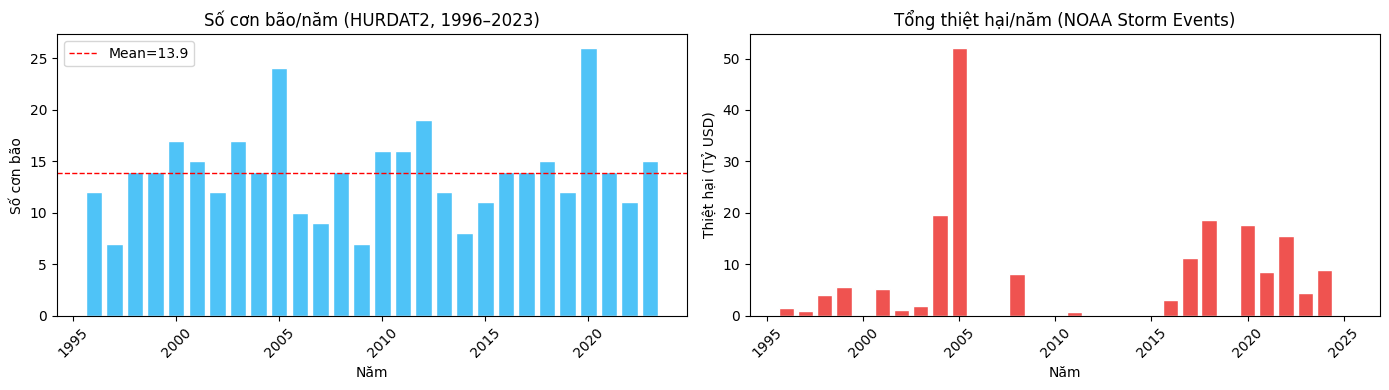

In [21]:
# ── 5.1 Số bão theo năm ─────────────────────────────────────────────────────────
storms_per_year = df_6h.groupby('year')['storm_id'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(storms_per_year.index, storms_per_year.values, color='#4fc3f7', edgecolor='white', width=0.8)
axes[0].set_xlabel('Năm'); axes[0].set_ylabel('Số cơn bão')
axes[0].set_title('Số cơn bão/năm (HURDAT2, 1996–2023)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(storms_per_year.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean={storms_per_year.mean():.1f}')
axes[0].legend()

# Thiệt hại theo năm (NOAA)
dmg_yr = noaa.groupby('YEAR')['damage_total_usd'].sum() / 1e9
axes[1].bar(dmg_yr.index, dmg_yr.values, color='#ef5350', edgecolor='white', width=0.8)
axes[1].set_xlabel('Năm'); axes[1].set_ylabel('Thiệt hại (Tỷ USD)')
axes[1].set_title('Tổng thiệt hại/năm (NOAA Storm Events)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(PLOT_DIR/'01_storms_and_damage_by_year.png', dpi=150, bbox_inches='tight')
plt.show()


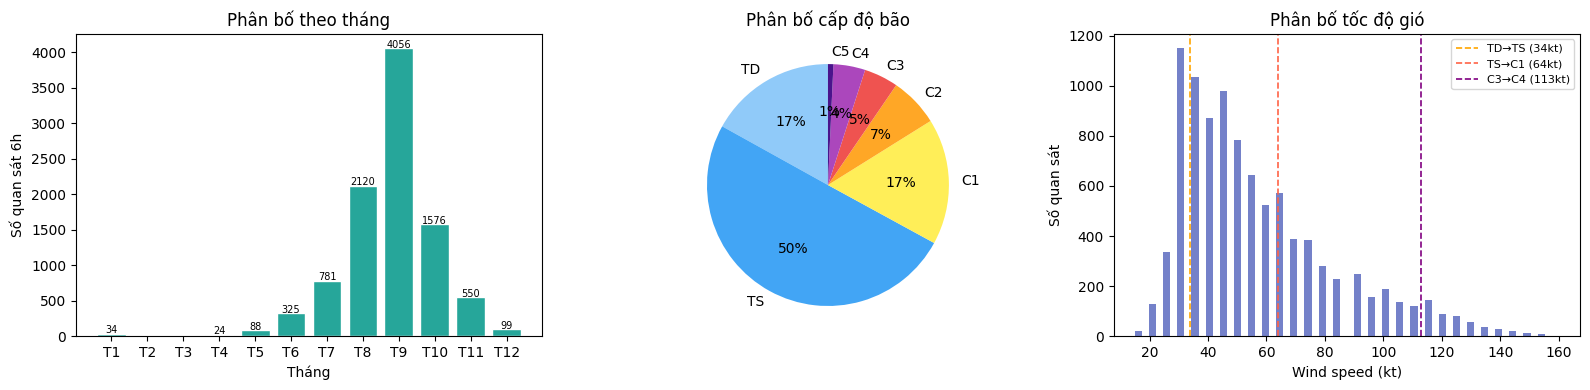

In [22]:
# ── 5.2 Phân bố tháng & cường độ ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Tháng
mc = df_6h.groupby('month').size()
bars = axes[0].bar(mc.index, mc.values, color='#26a69a', edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12'])
axes[0].set_xlabel('Tháng'); axes[0].set_ylabel('Số quan sát 6h')
axes[0].set_title('Phân bố theo tháng')
for b in bars:
    if b.get_height() > 0:
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+5,
                     str(int(b.get_height())), ha='center', fontsize=7)

# Cường độ Pie
cnt = df_6h['intensity_label'].value_counts()
order = [k for k in INTENSITY_COLORS if k in cnt.index]
axes[1].pie([cnt[k] for k in order],
            labels=order, colors=[INTENSITY_COLORS[k] for k in order],
            autopct='%1.0f%%', startangle=90)
axes[1].set_title('Phân bố cấp độ bão')

# Wind speed histogram
axes[2].hist(df_6h['wind_kt'].dropna(), bins=60, color='#5c6bc0', edgecolor='none', alpha=0.85)
for kt, lbl, clr in [(34,'TD→TS','orange'),(64,'TS→C1','tomato'),(113,'C3→C4','purple')]:
    axes[2].axvline(kt, color=clr, linestyle='--', linewidth=1.2, label=f'{lbl} ({kt}kt)')
axes[2].set_xlabel('Wind speed (kt)'); axes[2].set_ylabel('Số quan sát')
axes[2].set_title('Phân bố tốc độ gió')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOT_DIR/'02_month_intensity_wind.png', dpi=150, bbox_inches='tight')
plt.show()


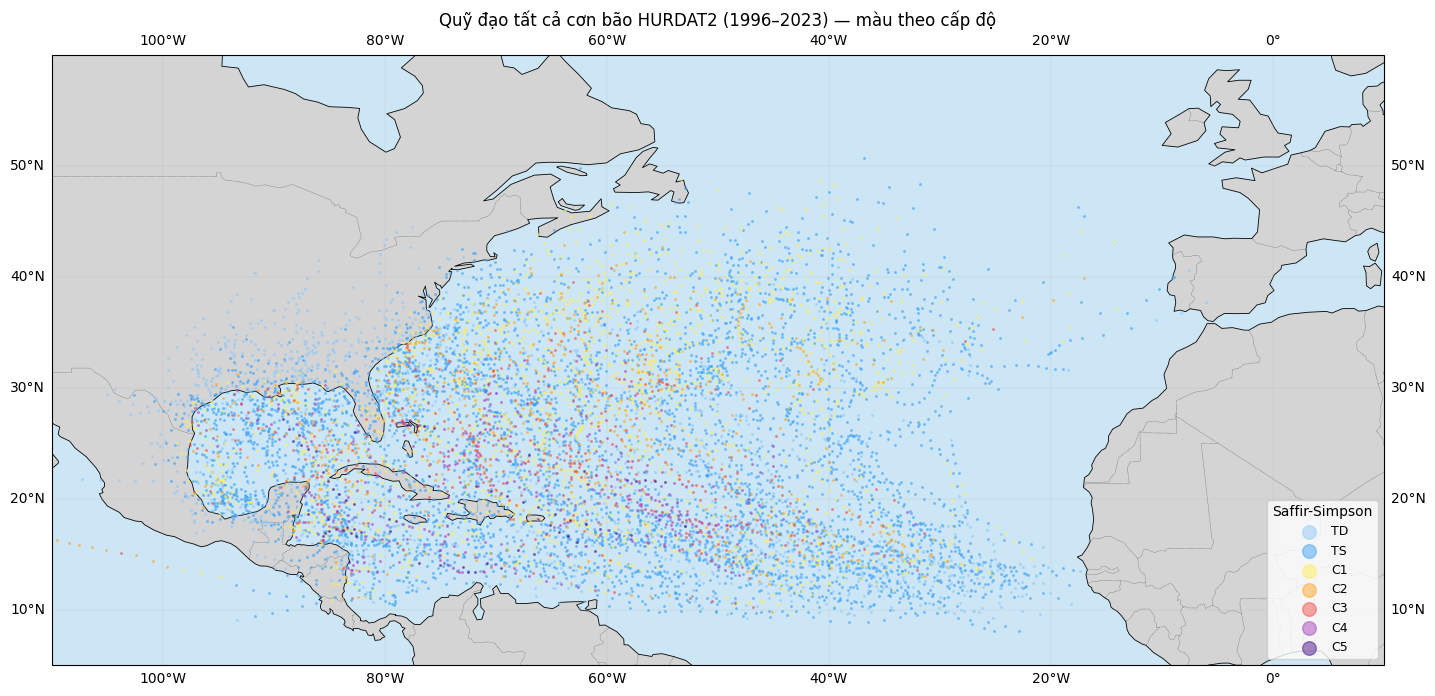

In [30]:
# ── 5.3 Bản đồ quỹ đạo tất cả bão ─────────────────────────────────────────────
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

fig = plt.figure(figsize=(15, 7))

if HAS_CARTOPY:
    ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
    ax.set_extent([-110, 10, 5, 60], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      facecolor='#d4d4d4')
    ax.add_feature(cfeature.OCEAN,     facecolor='#cce6f5')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=':')
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    tr = ccrs.PlateCarree()
else:
    ax = fig.add_subplot(1,1,1)
    ax.set_facecolor('#cce6f5')
    ax.set_xlim(-110, 10); ax.set_ylim(5, 60)
    ax.set_xlabel('Kinh độ (°)'); ax.set_ylabel('Vĩ độ (°)')
    tr = None

for lbl, clr in INTENSITY_COLORS.items():
    sub = df_6h[df_6h['intensity_label'] == lbl]
    kw  = dict(s=1.5, color=clr, alpha=0.5, label=lbl, zorder=3)
    if HAS_CARTOPY: ax.scatter(sub['lon'], sub['lat'], transform=tr, **kw)
    else:           ax.scatter(sub['lon'], sub['lat'], **kw)

ax.legend(markerscale=8, title='Saffir-Simpson', fontsize=9, loc='lower right')
ax.set_title('Quỹ đạo tất cả cơn bão HURDAT2 (1996–2023) — màu theo cấp độ', fontsize=12)

plt.tight_layout()
plt.savefig(PLOT_DIR/'03_all_tracks_map.png', dpi=150, bbox_inches='tight')
plt.show()


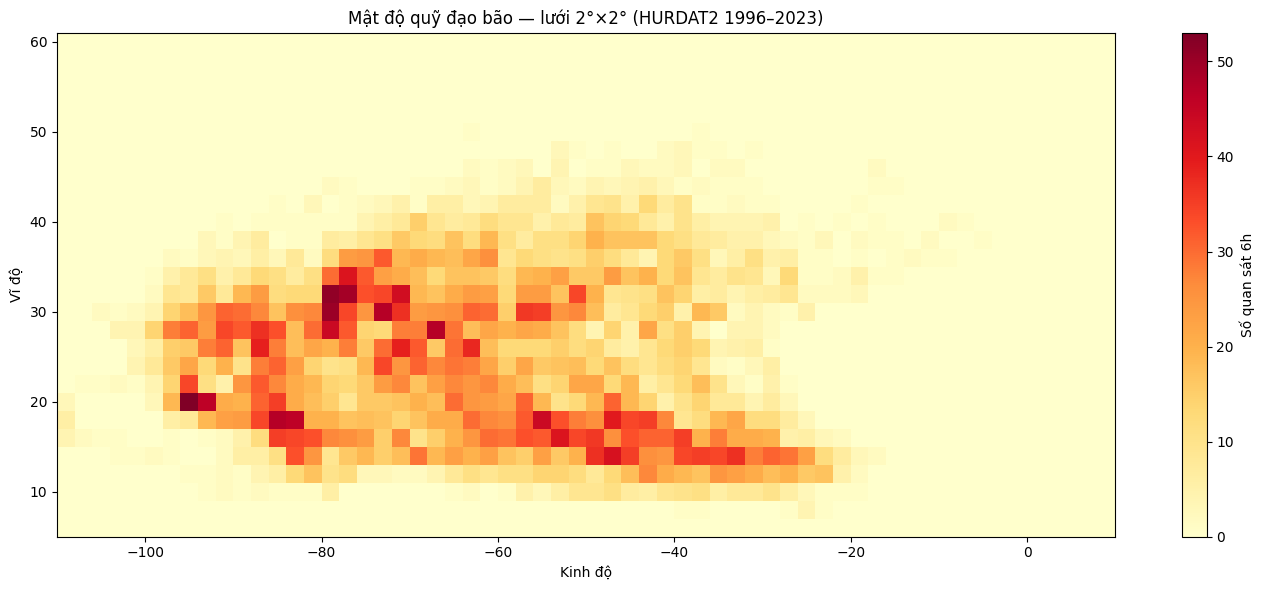

In [31]:
# ── 5.4 Mật độ bão (heatmap lưới 2°×2°) ───────────────────────────────────────
lon_bins = np.arange(-110, 12, 2)
lat_bins = np.arange(5, 62, 2)

heat, xe, ye = np.histogram2d(
    df_6h['lon'].clip(-110, 10),
    df_6h['lat'].clip(5, 60),
    bins=[lon_bins, lat_bins]
)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.pcolormesh(xe, ye, heat.T, cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Số quan sát 6h')
ax.set_xlabel('Kinh độ'); ax.set_ylabel('Vĩ độ')
ax.set_title('Mật độ quỹ đạo bão — lưới 2°×2° (HURDAT2 1996–2023)')
plt.tight_layout()
plt.savefig(PLOT_DIR/'04_density_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


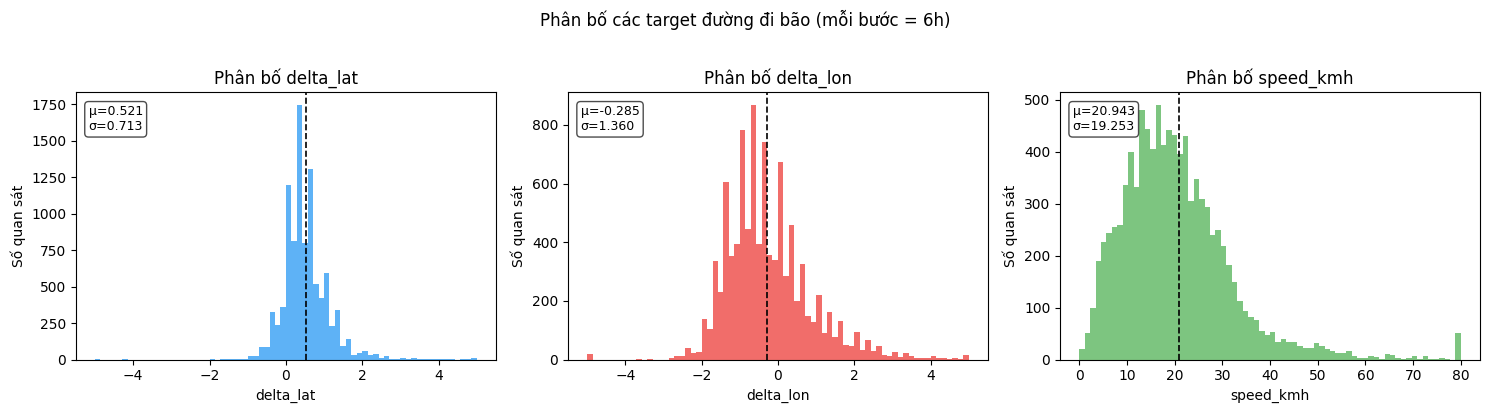

In [32]:
# ── 5.5 Phân bố Δlat / Δlon / speed (TARGET chính của model) ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, clr in [
    (axes[0], 'delta_lat', '#42a5f5'),
    (axes[1], 'delta_lon', '#ef5350'),
    (axes[2], 'speed_kmh', '#66bb6a'),
]:
    data = df_6h[col].dropna()
    clip_val = 5 if 'delta' in col else 80
    axes[list(axes).index(ax)].hist(
        data.clip(-clip_val, clip_val) if 'delta' in col else data.clip(0, clip_val),
        bins=70, color=clr, edgecolor='none', alpha=0.85
    )
    ax.axvline(data.mean(), color='black', linewidth=1.2, linestyle='--')
    ax.set_xlabel(col); ax.set_ylabel('Số quan sát')
    ax.set_title(f'Phân bố {col}')
    ax.text(0.03, 0.95, f'μ={data.mean():.3f}\nσ={data.std():.3f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('Phân bố các target đường đi bão (mỗi bước = 6h)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR/'05_target_motion_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


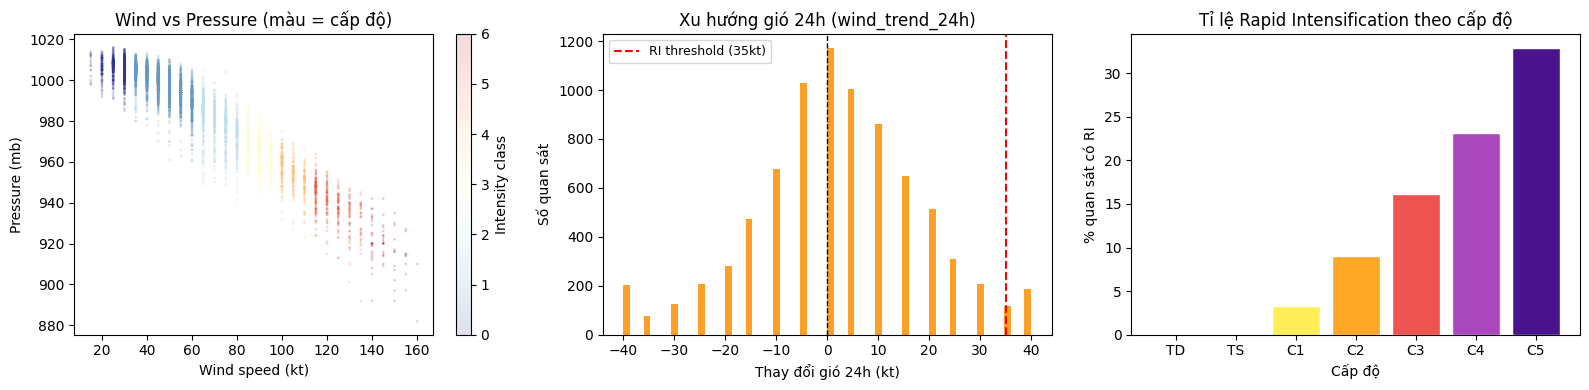

In [33]:
# ── 5.6 Wind & Pressure — scatter & xu hướng ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Scatter wind vs pressure
sc = axes[0].scatter(
    df_6h['wind_kt'], df_6h['pressure_mb'],
    s=1, alpha=0.15, c=df_6h['intensity_class'].fillna(0),
    cmap='RdYlBu_r', vmin=0, vmax=6
)
plt.colorbar(sc, ax=axes[0], label='Intensity class')
axes[0].set_xlabel('Wind speed (kt)'); axes[0].set_ylabel('Pressure (mb)')
axes[0].set_title('Wind vs Pressure (màu = cấp độ)')

# Wind trend 24h
axes[1].hist(df_6h['wind_trend_24h'].dropna().clip(-40, 40), bins=60,
             color='#ff8f00', edgecolor='none', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].axvline(35, color='red', linewidth=1.5, linestyle='--', label='RI threshold (35kt)')
axes[1].set_xlabel('Thay đổi gió 24h (kt)'); axes[1].set_ylabel('Số quan sát')
axes[1].set_title('Xu hướng gió 24h (wind_trend_24h)')
axes[1].legend(fontsize=9)

# RI rate
ri_rate = df_6h.groupby('intensity_label')['is_RI'].mean() * 100
ri_order = [k for k in INTENSITY_COLORS if k in ri_rate.index]
axes[2].bar(ri_order, [ri_rate.get(k,0) for k in ri_order],
            color=[INTENSITY_COLORS[k] for k in ri_order], edgecolor='white')
axes[2].set_xlabel('Cấp độ'); axes[2].set_ylabel('% quan sát có RI')
axes[2].set_title('Tỉ lệ Rapid Intensification theo cấp độ')

plt.tight_layout()
plt.savefig(PLOT_DIR/'06_wind_pressure_RI.png', dpi=150, bbox_inches='tight')
plt.show()


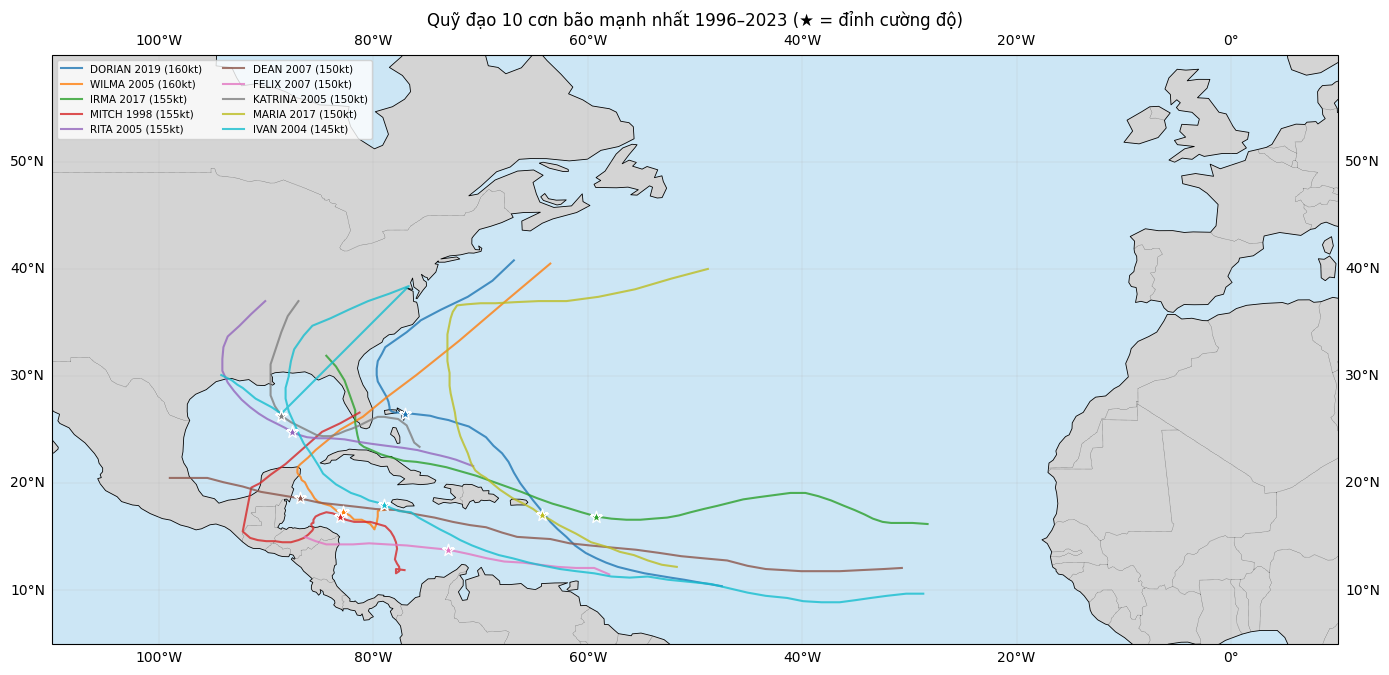


Top 10 bão mạnh nhất:


,peak_wind,storm_name,peak_year
storm_id,,,
AL052019,160.0,DORIAN,2019
AL252005,160.0,WILMA,2005
AL112017,155.0,IRMA,2017
AL131998,155.0,MITCH,1998
AL182005,155.0,RITA,2005
AL042007,150.0,DEAN,2007
AL062007,150.0,FELIX,2007
AL122005,150.0,KATRINA,2005
AL152017,150.0,MARIA,2017


In [36]:
# # ── 5.7 Quỹ đạo top 10 bão mạnh nhất ─────────────────────────────────────────
# peak = df_6h.groupby('storm_id').agg(
#     peak_wind   = ('wind_kt', 'max'),
#     storm_name  = ('storm_name', 'first'),
#     peak_year   = ('year', 'first'),
# ).nlargest(10, 'peak_wind')

# fig, ax = plt.subplots(figsize=(14, 7))
# ax.set_facecolor('#d6eaf8')
# ax.set_xlim(-110, 10); ax.set_ylim(5, 60)
# cmap_tr = plt.cm.tab10

# for i, (sid, row) in enumerate(peak.iterrows()):
#     sub  = df_6h[df_6h['storm_id']==sid].sort_values('timestamp')
#     clr  = cmap_tr(i/10)
#     ax.plot(sub['lon'], sub['lat'], '-', linewidth=1.5, color=clr, alpha=0.8,
#             label=f"{row['storm_name']} {row['peak_year']} ({row['peak_wind']:.0f}kt)")
#     # Đánh dấu điểm peak
#     pk = sub.loc[sub['wind_kt'].idxmax()]
#     ax.scatter(pk['lon'], pk['lat'], s=80, color=clr, edgecolors='white',
#                linewidths=1, zorder=5, marker='*')

# ax.set_xlabel('Kinh độ (°)'); ax.set_ylabel('Vĩ độ (°)')
# ax.set_title('Quỹ đạo 10 cơn bão mạnh nhất 1996–2023 (★ = đỉnh cường độ)')
# ax.legend(fontsize=7.5, loc='upper left', ncol=2)
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig(PLOT_DIR/'07_top10_strongest_tracks.png', dpi=150, bbox_inches='tight')
# plt.show()

# print('\nTop 10 bão mạnh nhất:')
# display(peak)
# ── 5.7 Quỹ đạo top 10 bão mạnh nhất ─────────────────────────────────────────

# Kiểm tra thư viện cartopy
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("Cảnh báo: Chưa cài đặt cartopy. Bản đồ sẽ hiển thị dưới dạng nền trơn.")

# 1. Lọc dữ liệu top 10
peak = df_6h.groupby('storm_id').agg(
    peak_wind   = ('wind_kt', 'max'),
    storm_name  = ('storm_name', 'first'),
    peak_year   = ('year', 'first'),
).nlargest(10, 'peak_wind')

# 2. Khởi tạo Figure và Axes
if HAS_CARTOPY:
    # Tạo axes có phép chiếu bản đồ
    fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([-110, 10, 5, 60], crs=ccrs.PlateCarree())
    
    # Thêm các lớp địa lý
    ax.add_feature(cfeature.LAND, facecolor='#d4d4d4')
    ax.add_feature(cfeature.OCEAN, facecolor='#cce6f5')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    tr = ccrs.PlateCarree() # Lưu đối tượng transform để dùng cho hàm plot
else:
    # Fallback nếu không có cartopy
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_facecolor('#d6eaf8')
    ax.set_xlim(-110, 10); ax.set_ylim(5, 60)
    ax.set_xlabel('Kinh độ (°)'); ax.set_ylabel('Vĩ độ (°)')
    ax.grid(True, alpha=0.3)
    tr = None

cmap_tr = plt.cm.tab10

# 3. Vẽ dữ liệu
for i, (sid, row) in enumerate(peak.iterrows()):
    sub  = df_6h[df_6h['storm_id']==sid].sort_values('timestamp')
    clr  = cmap_tr(i/10)
    
    # Chuẩn bị tham số vẽ đường
    kw_plot = dict(linewidth=1.5, color=clr, alpha=0.8, 
                   label=f"{row['storm_name']} {row['peak_year']} ({row['peak_wind']:.0f}kt)")
    
    # Vẽ quỹ đạo (plot)
    if HAS_CARTOPY:
        ax.plot(sub['lon'], sub['lat'], '-', transform=tr, **kw_plot)
    else:
        ax.plot(sub['lon'], sub['lat'], '-', **kw_plot)
        
    # Đánh dấu điểm đỉnh cường độ (scatter)
    pk = sub.loc[sub['wind_kt'].idxmax()]
    kw_scatter = dict(s=80, color=clr, edgecolors='white', linewidths=1, zorder=5, marker='*')
    
    if HAS_CARTOPY:
        ax.scatter(pk['lon'], pk['lat'], transform=tr, **kw_scatter)
    else:
        ax.scatter(pk['lon'], pk['lat'], **kw_scatter)

# 4. Tùy chỉnh và hiển thị
ax.set_title('Quỹ đạo 10 cơn bão mạnh nhất 1996–2023 (★ = đỉnh cường độ)', fontsize=12)
ax.legend(fontsize=7.5, loc='upper left', ncol=2)

plt.tight_layout()
# Bỏ comment dòng dưới nếu bạn muốn lưu ảnh
# plt.savefig(PLOT_DIR/'07_top10_strongest_tracks.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 bão mạnh nhất:')
display(peak)


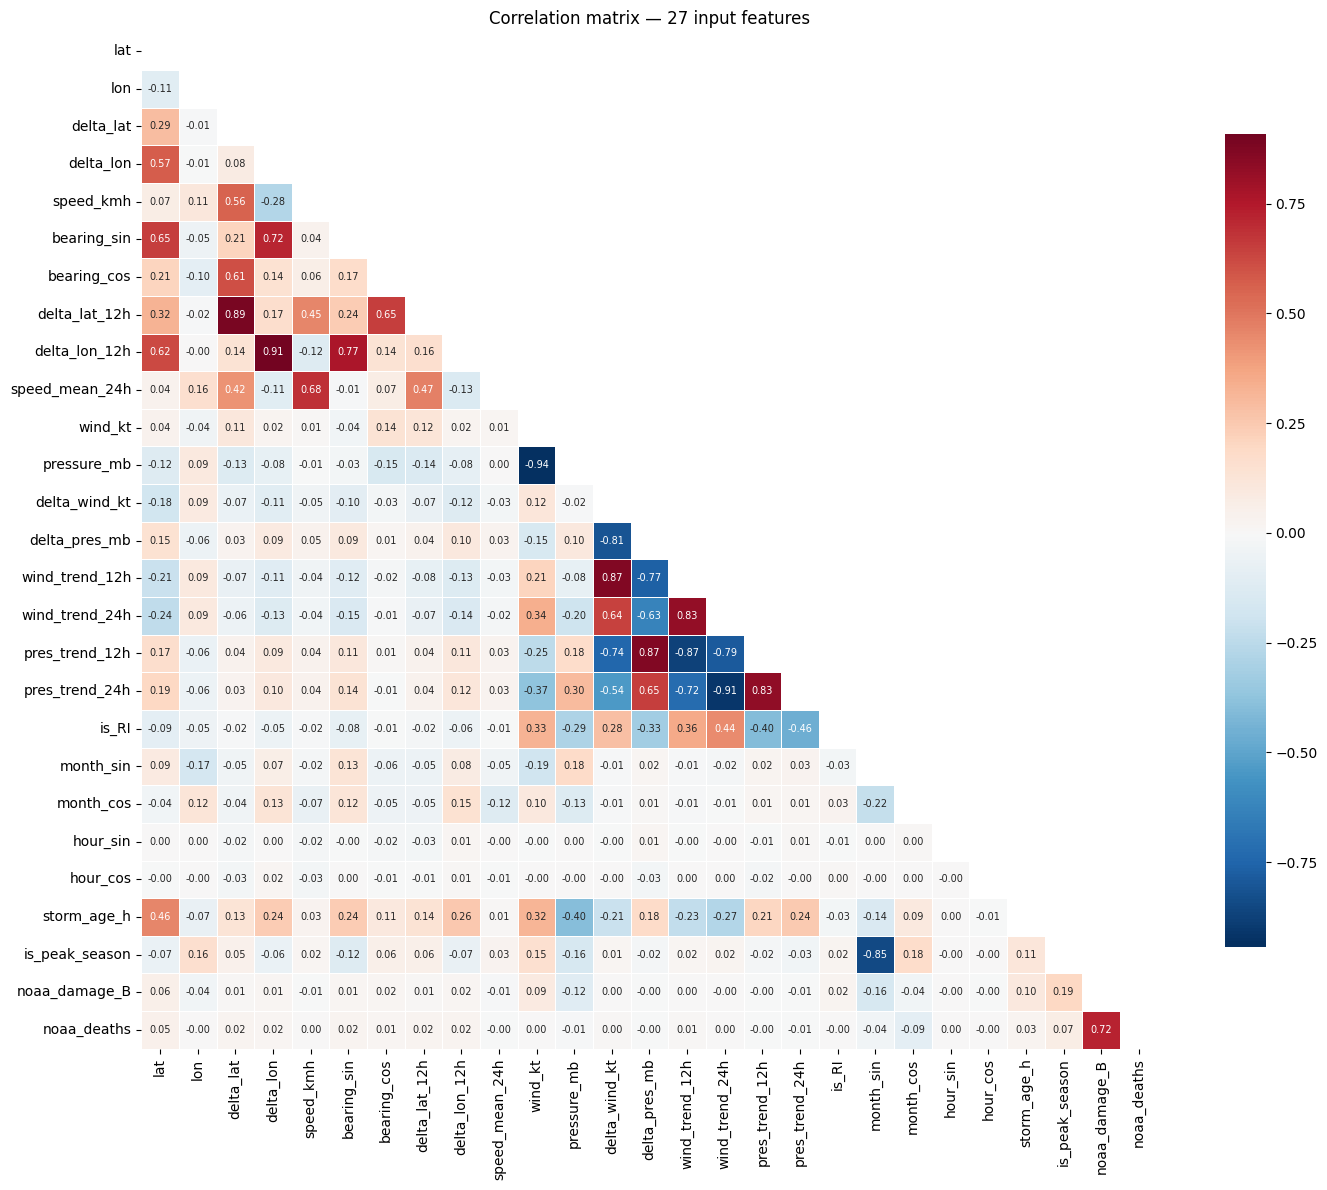

In [28]:
# ── 5.8 Correlation matrix của input features ───────────────────────────────────
feat_ok  = [f for f in INPUT_FEATURES if f in df_6h.columns]
corr_mat = df_6h[feat_ok].corr()
mask     = np.triu(np.ones_like(corr_mat, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.4, ax=ax,
            annot_kws={'size':7}, cbar_kws={'shrink':0.8})
ax.set_title(f'Correlation matrix — {len(feat_ok)} input features', fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR/'08_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


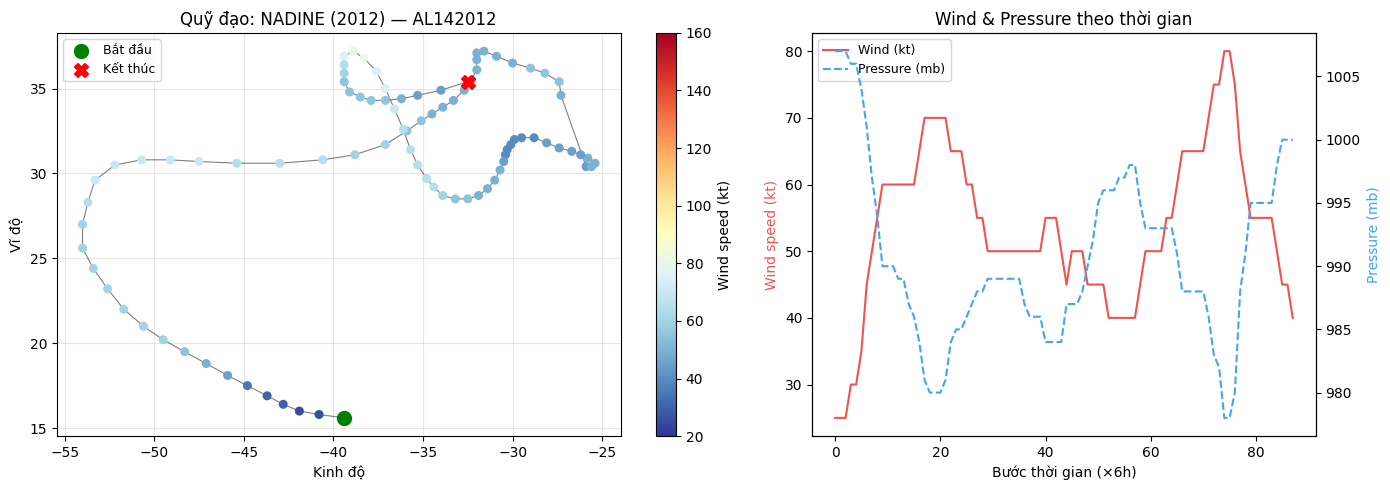

In [35]:
# ── 5.9 Vẽ 1 quỹ đạo cụ thể + cường độ theo thời gian ─────────────────────────
# Chọn bão có nhiều obs nhất trong dataset
most_obs = df_6h.groupby('storm_id').size().idxmax()
ex = df_6h[df_6h['storm_id'] == most_obs].sort_values('timestamp')

fig = plt.figure(figsize=(14, 5))
gs  = fig.add_gridspec(1, 2, width_ratios=[1.4, 1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# Quỹ đạo
sc = ax1.scatter(ex['lon'], ex['lat'], c=ex['wind_kt'], cmap='RdYlBu_r',
                 s=30, zorder=3, vmin=20, vmax=160)
ax1.plot(ex['lon'], ex['lat'], 'k-', linewidth=0.8, alpha=0.5)
ax1.scatter(ex['lon'].iloc[0], ex['lat'].iloc[0], s=100, color='green',
            zorder=5, marker='o', label='Bắt đầu')
ax1.scatter(ex['lon'].iloc[-1], ex['lat'].iloc[-1], s=100, color='red',
            zorder=5, marker='X', label='Kết thúc')
plt.colorbar(sc, ax=ax1, label='Wind speed (kt)')
ax1.set_title(f"Quỹ đạo: {ex['storm_name'].iloc[0]} ({ex['year'].iloc[0]}) — {most_obs}")
ax1.set_xlabel('Kinh độ'); ax1.set_ylabel('Vĩ độ')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# Wind & Pressure theo thời gian
ax2.plot(range(len(ex)), ex['wind_kt'], color='#ef5350', label='Wind (kt)')
ax2_twin = ax2.twinx()
ax2_twin.plot(range(len(ex)), ex['pressure_mb'], color='#42a5f5',
              linestyle='--', label='Pressure (mb)')
ax2.set_xlabel('Bước thời gian (×6h)')
ax2.set_ylabel('Wind speed (kt)', color='#ef5350')
ax2_twin.set_ylabel('Pressure (mb)', color='#42a5f5')
ax2.set_title('Wind & Pressure theo thời gian')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR/'09_sample_storm_track.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Gợi ý Model Tối ưu cho Dự đoán Bão

### Kiến trúc: **Bi-LSTM + Transformer Encoder (Hybrid)**

```
Input chuỗi 8 bước [B, 8, 28]  (48h lịch sử)
         ↓
  [Bi-LSTM Encoder]          ← nắm bắt xu hướng ngắn hạn, RI
  hidden_size=256, layers=2
         ↓
  [Transformer Encoder]      ← attention across time steps
  d_model=256, heads=8, layers=2
         ↓
  [Multi-Head Output]
  ├── Track Head (FC)        → Δlat, Δlon tại 5 horizons
  ├── Intensity Head (FC)    → wind_kt, pressure_mb tại 5 horizons
  └── Class Head (FC+Softmax)→ intensity_class (7 classes)
```

### Tại sao chọn kiến trúc này?

| Tiêu chí | Lý do |
|----------|-------|
| LSTM | Xử lý tốt chuỗi ngắn (8-24 bước), nhớ xu hướng tức thời như RI |
| Bi-directional | Học cả hướng thuận & nghịch trong window (context đầy đủ) |
| Transformer Encoder | Self-attention: chú ý bước nào quan trọng nhất (peak intensity) |
| Multi-task | Đồng thời học đường đi + cường độ → chia sẻ representation |
| GPU | Cả LSTM và Transformer đều được tối ưu tốt trên CUDA |

### Loss function:
- **Track**: Haversine Loss (tính sai số theo km thực, không phải độ)
- **Intensity (regression)**: Huber Loss (robust với outliers)
- **Intensity (class)**: Focal Loss (giải quyết class imbalance TD/TS >> C4/C5)

### Metric đánh giá:
- Track: **MAE (km)** = Haversine distance giữa dự đoán và thực tế
- Intensity: **MAE (kt)** cho wind, **MAE (mb)** cho pressure
- Class: **Macro F1** (do imbalance)


In [29]:
print('=' * 65)
print('  TỔNG KẾT NOTEBOOK 1.0')
print('=' * 65)
print(f'  HURDAT2          : {len(df_6h):>6,} quan sát 6h | {df_6h["storm_id"].nunique()} bão')
print(f'  NOAA Storm Events: {len(noaa):>6,} sự kiện   | {noaa["EPISODE_ID"].nunique()} episodes')
print(f'  Năm dữ liệu      : {df_6h["year"].min()} – {df_6h["year"].max()}')
print(f'  Input features   : {len(INPUT_FEATURES)}')
print(f'  Horizons dự đoán : {HORIZONS_H}h')
print(f'  Output           : {FILE_OUT}')
print(f'  Model gợi ý      : Bi-LSTM + Transformer Encoder (Hybrid)')
print('=' * 65)
print('  → Notebook 2.0: Dataset Split & Sliding Window')
print('  → Notebook 3.0: Augmentation & PyTorch DataLoader (GPU)')
print('  → Notebook 4.0: Training Bi-LSTM + Transformer trên GPU')
print('  → Notebook 5.0: Evaluation & Comparison')
print('  → Notebook 6.0: Export ONNX & Inference')


  TỔNG KẾT NOTEBOOK 1.0
  HURDAT2          :  9,653 quan sát 6h | 388 bão
  NOAA Storm Events: 10,590 sự kiện   | 1387 episodes
  Năm dữ liệu      : 1996 – 2023
  Input features   : 27
  Horizons dự đoán : [6, 12, 24, 48, 72]h
  Output           : data\processed_storms.parquet
  Model gợi ý      : Bi-LSTM + Transformer Encoder (Hybrid)
  → Notebook 2.0: Dataset Split & Sliding Window
  → Notebook 3.0: Augmentation & PyTorch DataLoader (GPU)
  → Notebook 4.0: Training Bi-LSTM + Transformer trên GPU
  → Notebook 5.0: Evaluation & Comparison
  → Notebook 6.0: Export ONNX & Inference
